# SS26 Seminar: Benchmarking Deep Learning (DL)-Based Docking Tools

## Team 4 - DiffDock-Pocket: Dhanya, Divyashree


## Visualization of DiffDock-Pocket Full Dataset Results

**Dataset:** `full_test` -- full seminar test set

**Model:** DiffDock-Pocket, trained from scratch on the full `full_sealed_train` set (24,078 complexes) on a single A100-PCIE-40GB GPU

**Checkpoint:** `best_ema_model.pt` (lowest validation loss checkpoint across the run)

**Metric:** Symmetry-corrected heavy-atom RMSD (Top-1 pose, ranked by confidence), PoseBusters structural validity

**Poses per complex:** 3 (reduced from the paper's 40 due to compute time -- full-set inference at 40 poses was estimated at ~18 days on a single A100; 3 poses completes in a fraction of that while still allowing top-1 selection by confidence)



This notebook covers: training/validation loss curves, RMSD distribution, PoseBusters structural validity,
per-ligand breakdown, failure analysis, cumulative success curve, and summary statistics with discussion.

## 1. Imports & Setup

In [18]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('All imports OK')

All imports OK


In [19]:
TRAINING_LOG_PATH = "training_full.out"
EVAL_CSV_PATH = "full_test_evaluation_with_pb_3poses.csv"
EVAL_CSV_1POSE_PATH = "full_test_evaluation_with_pb.csv"
POSEBUSTERS_FILTERED_CSV_PATH = "posebusters_filtered_evaluation.csv"  

## 2. Training & Validation Loss (Full Run)

Training ran on a single A100-PCIE-40GB GPU (HTCondor cluster), using `--all_atom`, `--flexible_sidechains`,
`--pocket_reduction`, batch size 4 (reduced from the paper's 16 due to per-complex memory constraints even
after lowering `--receptor_radius` and `--c_alpha_max_neighbors`).

> **Note on validation loss:** the loss function divides by `tr_sigma`/`rot_score_norm`, which can be very
> small for individual validation complexes. This causes validation loss to occasionally spike by many
> orders of magnitude for a small number of complexes in a given epoch, even when training loss (which is
> gradient-clipped and averaged over many more samples per step) stays stable. Both curves are shown below;
> training loss is the more reliable signal for whether the model is learning.


In [20]:
def parse_training_log(path):
    """
    Parses train.py's stdout log and extracts per-epoch training/validation loss.
      Epoch 0: Training loss 1.0071  tr 0.9398   rot 1.0396   tor 1.0282  sc_tor 1.0208
      Epoch 0: Validation loss 3371829.9552  tr 6537229.0105   rot 6950090.0448 ...
    """
    train_pattern = re.compile(
        r"Epoch (\d+): Training loss ([\d.]+)\s+tr ([\d.]+)\s+rot ([\d.]+)\s+tor ([\d.]+)\s+sc_tor ([\d.]+)"
    )
    val_pattern = re.compile(
        r"Epoch (\d+): Validation loss ([\d.eE+-]+)\s+tr ([\d.eE+-]+)\s+rot ([\d.eE+-]+)\s+tor ([\d.eE+-]+)\s+sc_tor ([\d.eE+-]+)"
    )
    rows = {}
    with open(path) as f:
        for line in f:
            m = train_pattern.search(line)
            if m:
                e = int(m.group(1))
                rows.setdefault(e, {}).update({
                    "train_loss": float(m.group(2)), "train_tr": float(m.group(3)),
                    "train_rot": float(m.group(4)), "train_tor": float(m.group(5)),
                    "train_sc_tor": float(m.group(6)),
                })
                continue
            m = val_pattern.search(line)
            if m:
                e = int(m.group(1))
                rows.setdefault(e, {}).update({
                    "val_loss": float(m.group(2)), "val_tr": float(m.group(3)),
                    "val_rot": float(m.group(4)), "val_tor": float(m.group(5)),
                    "val_sc_tor": float(m.group(6)),
                })
    df = pd.DataFrame.from_dict(rows, orient="index").sort_index()
    df.index.name = "epoch"
    return df

training_df = parse_training_log(TRAINING_LOG_PATH)
print(f"Parsed {len(training_df)} epochs")
training_df.head(10)

Parsed 109 epochs


,train_loss,train_tr,train_rot,train_tor,train_sc_tor,val_loss,val_tr,val_rot,val_tor,val_sc_tor
epoch,,,,,,,,,,
0,1.0071,0.9398,1.0396,1.0282,1.0208,3.371830e+06,6.537229e+06,6.950090e+06,1.0271,1.0532
1,0.9863,0.8864,1.0351,1.0104,1.0131,5.293089e+04,4.856040e+04,1.631621e+05,0.9767,0.9965
2,0.9822,0.8674,1.0415,1.0103,1.0095,3.688652e+08,8.187232e+08,6.567376e+08,0.9833,1.0011
3,0.9859,0.8898,1.0404,1.0127,1.0008,6.074441e+10,1.375761e+11,1.054016e+11,1.0069,0.9947
4,0.9901,0.8967,1.0575,1.0069,0.9992,6.453192e+02,1.321653e+03,1.257672e+03,0.9746,0.9769
5,0.9919,0.9066,1.0563,0.9996,1.0052,4.650880e+07,1.108431e+08,7.519204e+07,0.9583,0.9942
6,0.9944,0.9053,1.0521,1.0108,1.0093,3.257262e+05,2.399553e+05,1.062948e+06,0.9648,1.0078
7,0.9931,0.9227,1.0454,1.0039,1.0003,2.972490e+09,2.391805e+09,9.498157e+09,0.9756,0.9819
8,1.0023,0.9433,1.0447,1.0135,1.0079,7.304381e+08,4.800448e+08,2.441708e+09,0.9968,0.9867


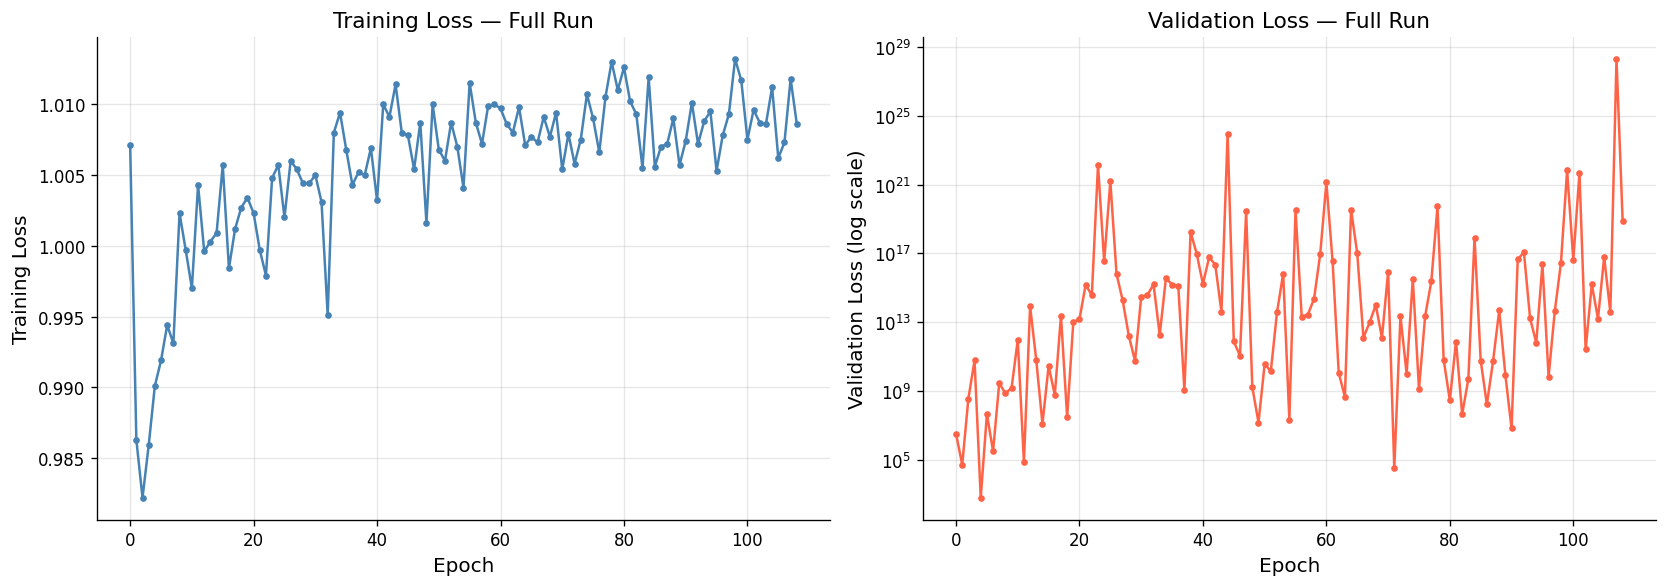

Best validation loss: 645.3192 at epoch 4
Final training loss (epoch 108): 1.0086


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(training_df.index, training_df['train_loss'], marker='o', markersize=3,
             linewidth=1.5, color='steelblue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss — Full Run', fontsize=13)
axes[0].grid(alpha=0.3)

axes[1].plot(training_df.index, training_df['val_loss'], marker='o', markersize=3,
             linewidth=1.5, color='tomato')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss (log scale)', fontsize=12)
axes[1].set_title('Validation Loss — Full Run', fontsize=13)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('training_loss_full.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = training_df['val_loss'].idxmin()
print(f"Best validation loss: {training_df.loc[best_epoch, 'val_loss']:.4f} at epoch {best_epoch}")
print(f"Final training loss (epoch {training_df.index[-1]}): {training_df['train_loss'].iloc[-1]:.4f}")

## 3. Load Evaluation Results (Full Test Set, 3 poses/complex)

The evaluation CSV contains one row per (complex, pose) pair, with `pose_rank` indicating the
confidence ranking within each complex (1 = highest confidence / top pose). RMSD and PoseBusters
validity are reported per pose. For headline metrics we use `pose_rank == 1` (top pose), matching
the prototype notebook's Top-1 methodology.

In [22]:
eval_all = pd.read_csv(EVAL_CSV_PATH)
print(f"Loaded {len(eval_all)} rows ({eval_all['complex_id'].nunique()} unique complexes, "
      f"{eval_all['pose_rank'].nunique()} poses/complex)")

# top-1 pose per complex — this is the primary metric used throughout
eval_df = eval_all[eval_all['pose_rank'] == 1].copy()

eval_df['ligand_code'] = eval_df['complex_id'].apply(lambda x: x.split('_')[1] if '_' in x else x)
eval_df['pdb_id']      = eval_df['complex_id'].apply(lambda x: x.split('_')[0])

print(f"Top-1 poses: {len(eval_df)} complexes")
eval_df.head(10)

Loaded 5156 rows (5156 unique complexes, 1 poses/complex)
Top-1 poses: 5156 complexes


,complex_id,dataset,pose_rank,rmsd,rmsd_lt2,rmsd_lt1,ligand_file,protein_file,pb_valid,mol_pred_loaded,...,minimum_distance_to_protein,minimum_distance_to_organic_cofactors,minimum_distance_to_inorganic_cofactors,minimum_distance_to_waters,volume_overlap_with_protein,volume_overlap_with_organic_cofactors,volume_overlap_with_inorganic_cofactors,volume_overlap_with_waters,ligand_code,pdb_id
0,1a0q_HEP_H_214,full_test,1,2.0107,False,False,1a0q_HEP_H_214_ligand_refined.sdf,1a0q_HEP_H_214_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,HEP,1a0q
1,1a29_TFP_A_153,full_test,1,2.7846,False,False,1a29_TFP_A_153_ligand_refined.sdf,1a29_TFP_A_153_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,TFP,1a29
2,1a4m_PRH_A_354,full_test,1,0.7312,True,True,1a4m_PRH_A_354_ligand_refined.sdf,1a4m_PRH_A_354_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,PRH,1a4m
3,1a4m_PRH_B_854,full_test,1,1.5765,True,False,1a4m_PRH_B_854_ligand_refined.sdf,1a4m_PRH_B_854_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,PRH,1a4m
4,1a4m_PRH_C_1354,full_test,1,0.6073,True,True,1a4m_PRH_C_1354_ligand_refined.sdf,1a4m_PRH_C_1354_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,PRH,1a4m
5,1a4m_PRH_D_1854,full_test,1,0.8146,True,True,1a4m_PRH_D_1854_ligand_refined.sdf,1a4m_PRH_D_1854_protein_refined.pdb,True,True,...,True,True,True,True,True,True,True,True,PRH,1a4m
6,1a50_FIP_A_270,full_test,1,1.5883,True,False,1a50_FIP_A_270_ligand_refined.sdf,1a50_FIP_A_270_protein_refined.pdb,False,True,...,False,True,True,True,True,True,True,True,FIP,1a50
7,1a5s_FIP_A_270,full_test,1,2.3974,False,False,1a5s_FIP_A_270_ligand_refined.sdf,1a5s_FIP_A_270_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,FIP,1a5s
8,1a8g_2Z4_A_100,full_test,1,5.7948,False,False,1a8g_2Z4_A_100_ligand_refined.sdf,1a8g_2Z4_A_100_protein_refined.pdb,False,True,...,False,True,True,True,False,True,True,True,2Z4,1a8g
9,1a9m_U0E_B_100,full_test,1,3.4656,False,False,1a9m_U0E_B_100_ligand_refined.sdf,1a9m_U0E_B_100_protein_refined.pdb,False,True,...,False,True,True,True,True,True,True,True,U0E,1a9m


## 4. Summary Statistics (Top-1 Pose)

In [37]:
n_complexes  = len(eval_df)
success_2A   = eval_df['rmsd_lt2'].mean() * 100
success_1A   = eval_df['rmsd_lt1'].mean() * 100
median_rmsd  = eval_df['rmsd'].median()
mean_rmsd    = eval_df['rmsd'].mean()
pb_valid_pct = eval_df['pb_valid'].mean() * 100

print('-' * 50)
print('DiffDock-Pocket — full_test Results (Top-1, 3 poses)')
print('-' * 50)
print(f'  Complexes evaluated  : {n_complexes}')
print(f'  RMSD < 2.0 Å (Top-1) : {success_2A:.1f}%  ({eval_df["rmsd_lt2"].sum()}/{n_complexes})')
print(f'  RMSD < 1.0 Å (Top-1) : {success_1A:.1f}%  ({eval_df["rmsd_lt1"].sum()}/{n_complexes})')
print(f'  Median RMSD           : {median_rmsd:.3f} Å')
print(f'  Mean RMSD              : {mean_rmsd:.3f} Å')
print(f'  PoseBusters valid      : {pb_valid_pct:.1f}%  ({eval_df["pb_valid"].sum()}/{n_complexes})')

--------------------------------------------------
DiffDock-Pocket — full_test Results (Top-1, 3 poses)
--------------------------------------------------
  Complexes evaluated  : 5156
  RMSD < 2.0 Å (Top-1) : 50.3%  (2596/5156)
  RMSD < 1.0 Å (Top-1) : 16.3%  (840/5156)
  Median RMSD           : 1.988 Å
  Mean RMSD              : 2.124 Å
  PoseBusters valid      : 6.6%  (341/5156)


## 5. Effect of Pose Count: 1 vs 3 poses/complex

Comparing the 1-pose run against the 3-pose run to show the accuracy/compute trade-off.

                          1 pose    3 poses
RMSD < 2Å (%)          50.171336  50.349108
RMSD < 1Å (%)          16.750655  16.291699
PoseBusters valid (%)   5.422294   6.613654


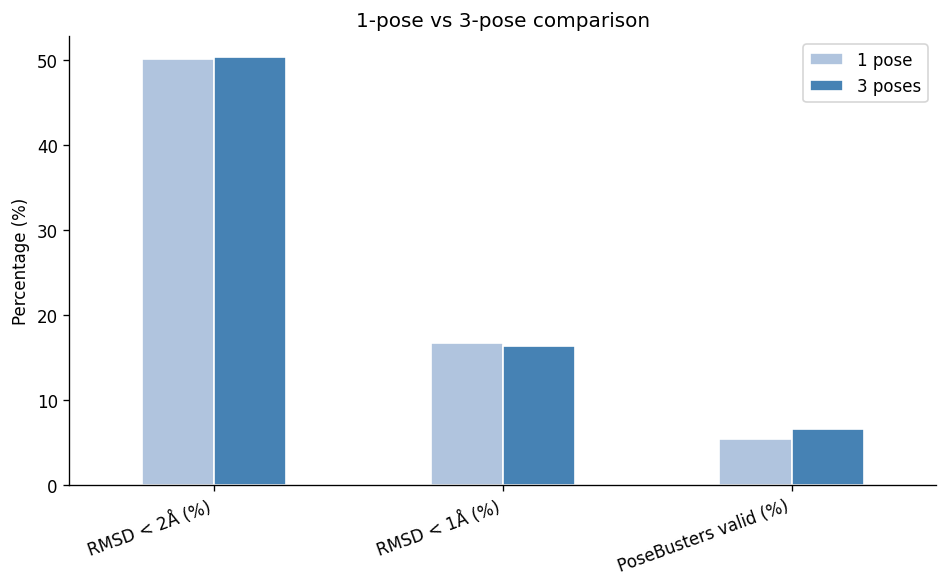

In [24]:
try:
    eval_1pose_all = pd.read_csv(EVAL_CSV_1POSE_PATH)
    eval_1pose = eval_1pose_all[eval_1pose_all['pose_rank'] == 1].copy()

    comparison = pd.DataFrame({
        '1 pose':  [eval_1pose['rmsd_lt2'].mean()*100, eval_1pose['rmsd_lt1'].mean()*100, eval_1pose['pb_valid'].mean()*100],
        '3 poses': [success_2A, success_1A, pb_valid_pct],
    }, index=['RMSD < 2Å (%)', 'RMSD < 1Å (%)', 'PoseBusters valid (%)'])

    print(comparison)

    fig, ax = plt.subplots(figsize=(8, 5))
    comparison.plot(kind='bar', ax=ax, color=['lightsteelblue', 'steelblue'], edgecolor='white')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('1-pose vs 3-pose comparison')
    ax.set_xticklabels(comparison.index, rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig('pose_count_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print(f"{EVAL_CSV_1POSE_PATH} not found — skipping comparison.")

## 6. RMSD Distribution — Full Test Set (Top-1)

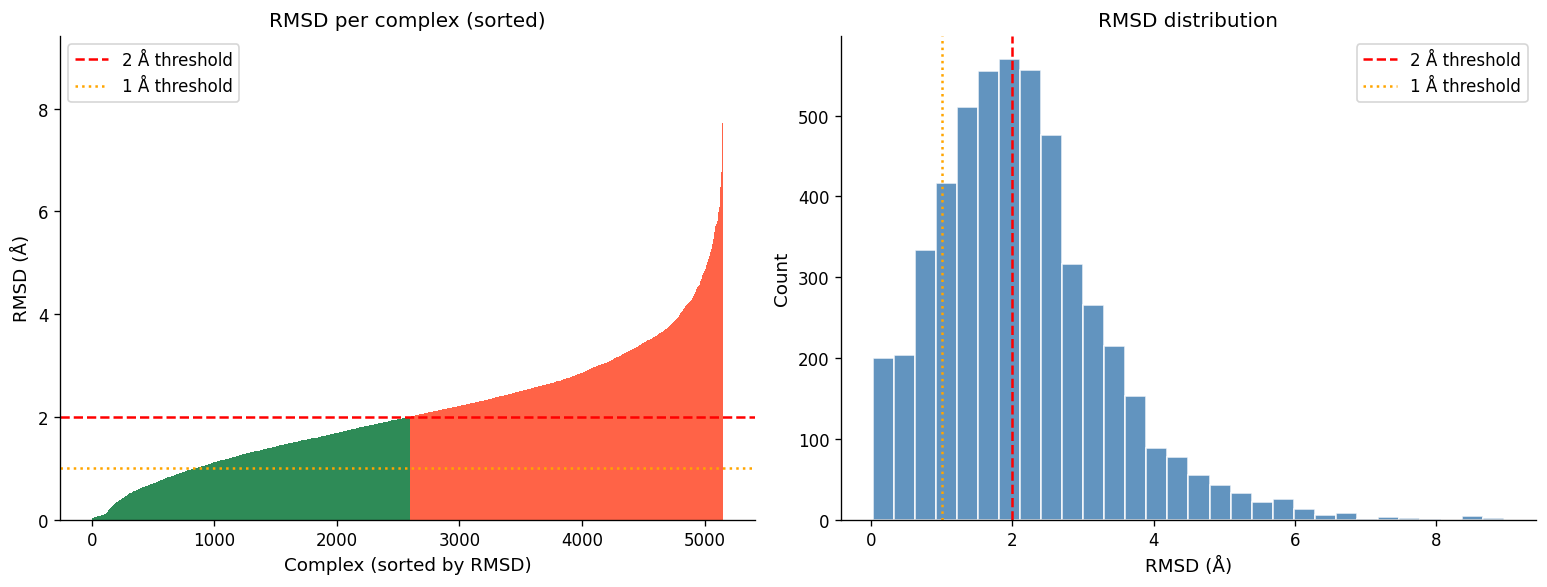

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sorted_rmsd = eval_df.sort_values('rmsd')['rmsd'].values
colors = ['seagreen' if r < 2.0 else 'tomato' for r in sorted_rmsd]
ax.bar(range(len(sorted_rmsd)), sorted_rmsd, color=colors, edgecolor='none', width=1.0)
ax.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='2 Å threshold')
ax.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='1 Å threshold')
ax.set_xlabel('Complex (sorted by RMSD)', fontsize=11)
ax.set_ylabel('RMSD (Å)', fontsize=11)
ax.set_title('RMSD per complex (sorted)', fontsize=12)
ax.legend()

ax = axes[1]
ax.hist(eval_df['rmsd'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='2 Å threshold')
ax.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='1 Å threshold')
ax.set_xlabel('RMSD (Å)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('RMSD distribution', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('rmsd_distribution_full.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PoseBusters Structural Validity

Per-check pass rates across all Top-1 poses. Columns are the individual PoseBusters checks present
directly in the evaluation CSV (chemistry sanity, geometry, protein-ligand contacts).

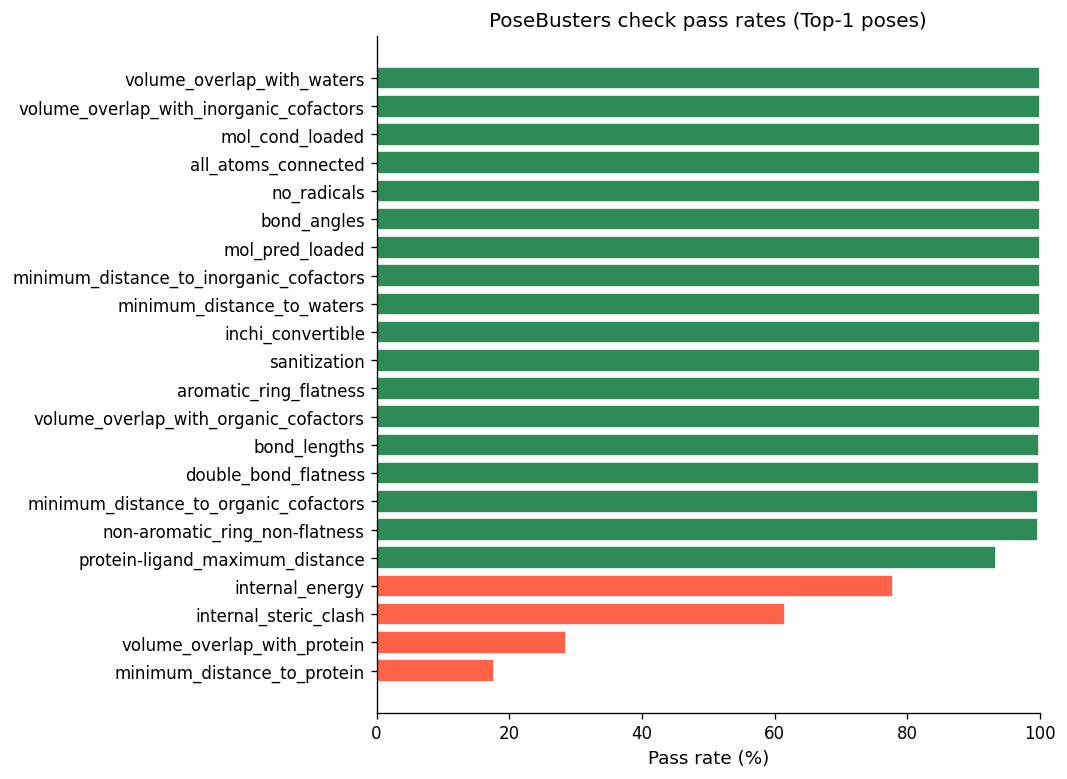


Overall pb_valid (all checks passed): 6.6%

Lowest-passing checks (potential systematic issues):
minimum_distance_to_protein        17.629946
volume_overlap_with_protein        28.510473
internal_steric_clash              61.493695
internal_energy                    77.861855
protein-ligand_maximum_distance    93.289372
dtype: object


In [26]:
pb_check_cols = [
    'mol_pred_loaded', 'mol_cond_loaded', 'sanitization', 'inchi_convertible',
    'all_atoms_connected', 'no_radicals', 'bond_lengths', 'bond_angles',
    'internal_steric_clash', 'aromatic_ring_flatness', 'non-aromatic_ring_non-flatness',
    'double_bond_flatness', 'internal_energy', 'protein-ligand_maximum_distance',
    'minimum_distance_to_protein', 'minimum_distance_to_organic_cofactors',
    'minimum_distance_to_inorganic_cofactors', 'minimum_distance_to_waters',
    'volume_overlap_with_protein', 'volume_overlap_with_organic_cofactors',
    'volume_overlap_with_inorganic_cofactors', 'volume_overlap_with_waters',
]
pb_check_cols = [c for c in pb_check_cols if c in eval_df.columns]

pass_rates = (eval_df[pb_check_cols].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, max(5, len(pb_check_cols) * 0.3)))
bar_colors = ['tomato' if v < 90 else 'seagreen' for v in pass_rates.values]
ax.barh(pass_rates.index, pass_rates.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Pass rate (%)', fontsize=11)
ax.set_title('PoseBusters check pass rates (Top-1 poses)', fontsize=12)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('posebusters_checks_full.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall pb_valid (all checks passed): {eval_df['pb_valid'].mean()*100:.1f}%")
print("\nLowest-passing checks (potential systematic issues):")
print(pass_rates.head(5))

## 8. Performance by Ligand Type

Per-ligand breakdown across the full test set (top 25 most frequent ligands shown for readability).

In [27]:
ligand_stats = eval_df.groupby('ligand_code').agg(
    count       = ('rmsd', 'count'),
    median_rmsd = ('rmsd', 'median'),
    success_2A  = ('rmsd_lt2', 'mean'),
    success_1A  = ('rmsd_lt1', 'mean'),
).reset_index().sort_values('count', ascending=False)

ligand_stats['success_2A_pct'] = (ligand_stats['success_2A'] * 100).round(1)
ligand_stats['success_1A_pct'] = (ligand_stats['success_1A'] * 100).round(1)
print(ligand_stats[['ligand_code','count','median_rmsd','success_2A_pct','success_1A_pct']].head(25).to_string(index=False))

ligand_code  count  median_rmsd  success_2A_pct  success_1A_pct
    ACE-NH2     19      3.51800             0.0             0.0
        IHP     15      2.20540            26.7             0.0
        4IP     14      1.94370            64.3             0.0
    OO1-MP8     14      3.74055             0.0             0.0
        TSA     14      0.82255           100.0            85.7
        ZEA     13      1.77190            69.2             7.7
        3PG     13      0.90630           100.0            69.2
        23J     12      1.09640           100.0            33.3
        PAU     12      1.67810            91.7             8.3
        ADK     11      0.06570           100.0           100.0
        X23     10      2.58525            10.0             0.0
        C0R     10      0.82215           100.0            60.0
        RES      9      1.73580           100.0            22.2
        BX7      9      2.79910             0.0             0.0
        LEC      9      1.85600         

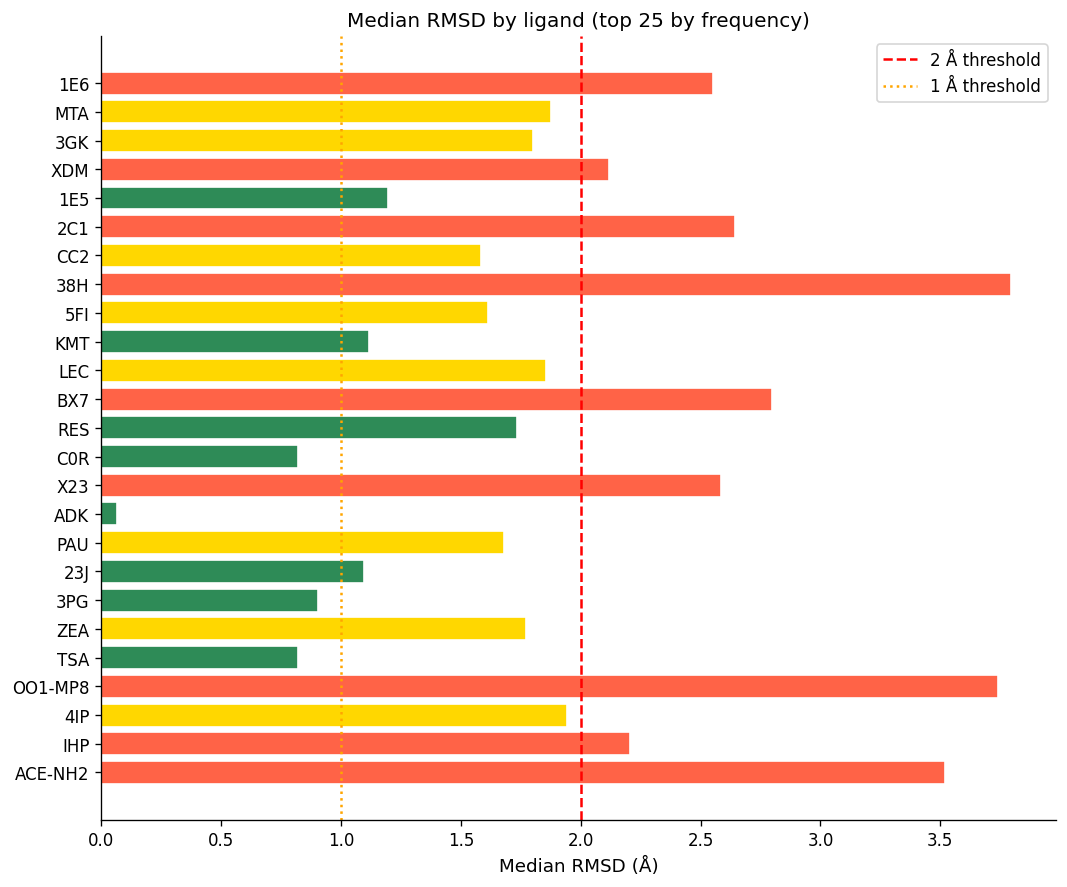

In [28]:
top_ligands = ligand_stats.head(25)

fig, ax = plt.subplots(figsize=(9, max(5, len(top_ligands) * 0.3)))
bar_colors = ['seagreen' if s == 100 else ('gold' if s >= 50 else 'tomato')
              for s in top_ligands['success_2A_pct']]
ax.barh(top_ligands['ligand_code'], top_ligands['median_rmsd'], color=bar_colors, edgecolor='white')
ax.axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='2 Å threshold')
ax.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='1 Å threshold')
ax.set_xlabel('Median RMSD (Å)', fontsize=11)
ax.set_title('Median RMSD by ligand (top 25 by frequency)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('rmsd_by_ligand_full.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Best and Worst Predictions

In [29]:
top10_best  = eval_df.nsmallest(10, 'rmsd')[['complex_id', 'ligand_code', 'rmsd', 'pb_valid']]
top10_worst = eval_df.nlargest(10, 'rmsd')[['complex_id', 'ligand_code', 'rmsd', 'pb_valid']]

print(' Top-10 Best Predictions:')
for _, row in top10_best.iterrows():
    print(f"  {row['complex_id']:<28} ligand={row['ligand_code']:<6} RMSD={row['rmsd']:.4f} Å  pb_valid={row['pb_valid']}")

print()
print(' Top-10 Worst Predictions:')
for _, row in top10_worst.iterrows():
    print(f"  {row['complex_id']:<28} ligand={row['ligand_code']:<6} RMSD={row['rmsd']:.4f} Å  pb_valid={row['pb_valid']}")

 Top-10 Best Predictions:
  3hhy_CAQ_A_282               ligand=CAQ    RMSD=0.0215 Å  pb_valid=False
  3fw4_CAQ_A_180               ligand=CAQ    RMSD=0.0246 Å  pb_valid=False
  3lb1_IOL_B_192               ligand=IOL    RMSD=0.0265 Å  pb_valid=False
  3lb1_IOL_A_191               ligand=IOL    RMSD=0.0270 Å  pb_valid=False
  3lb3_4CH_A_191               ligand=4CH    RMSD=0.0271 Å  pb_valid=False
  3fw4_CAQ_C_180               ligand=CAQ    RMSD=0.0277 Å  pb_valid=True
  3hj8_4CL_A_282               ligand=4CL    RMSD=0.0303 Å  pb_valid=False
  3lb3_4CH_B_192               ligand=4CH    RMSD=0.0319 Å  pb_valid=False
  4k7i_CAQ_B_201               ligand=CAQ    RMSD=0.0336 Å  pb_valid=False
  4qp2_36R_A_401               ligand=36R    RMSD=0.0348 Å  pb_valid=False

 Top-10 Worst Predictions:
  2puy_ALA-SER_E_1-10          ligand=ALA-SER RMSD=8.9640 Å  pb_valid=False
  5aei_LYS-ARG_E_1-10          ligand=LYS-ARG RMSD=8.8090 Å  pb_valid=False
  5aei_LYS-ARG_F_1-10          ligand=LYS-ARG

## 10. Failure Analysis

In [30]:
failures = eval_df[~eval_df['rmsd_lt2']].sort_values('rmsd', ascending=False)
print(f'Total failures (RMSD >= 2 Å): {len(failures)} / {len(eval_df)}  ({len(failures)/len(eval_df)*100:.1f}%)')
print()
print(failures[['complex_id', 'ligand_code', 'pdb_id', 'rmsd', 'pb_valid']].head(30).to_string(index=False))

Total failures (RMSD >= 2 Å): 2560 / 5156  (49.7%)

              complex_id ligand_code pdb_id   rmsd  pb_valid
     2puy_ALA-SER_E_1-10     ALA-SER   2puy 8.9640     False
     5aei_LYS-ARG_E_1-10     LYS-ARG   5aei 8.8090     False
     5aei_LYS-ARG_F_1-10     LYS-ARG   5aei 8.5694     False
          7amd_RMW_A_701         RMW   7amd 8.5421     False
     3llz_ASN-ASP_B_3-16     ASN-ASP   3llz 8.4056     False
    2bqz_ARG-TYR_F_17-26     ARG-TYR   2bqz 8.3812     False
    2bqz_ARG-TYR_B_17-26     ARG-TYR   2bqz 7.8390     False
     4k78_ALA-LEU_B_1-10     ALA-LEU   4k78 7.7197     False
         2vbq_BSJ_B_1146         BSJ   2vbq 7.5320     False
          4qjr_PIZ_A_501         PIZ   4qjr 7.4199     False
          1i5r_HYC_A_328         HYC   1i5r 7.3945     False
         2xeg_CI9_A_1768         CI9   2xeg 7.2939     False
2ast_ALA-LYS_D_4181-4190     ALA-LYS   2ast 7.0966     False
     6v2o_ALA-TRP_C_1-10     ALA-TRP   6v2o 6.8427     False
         2cb3_MLD_C_1344         

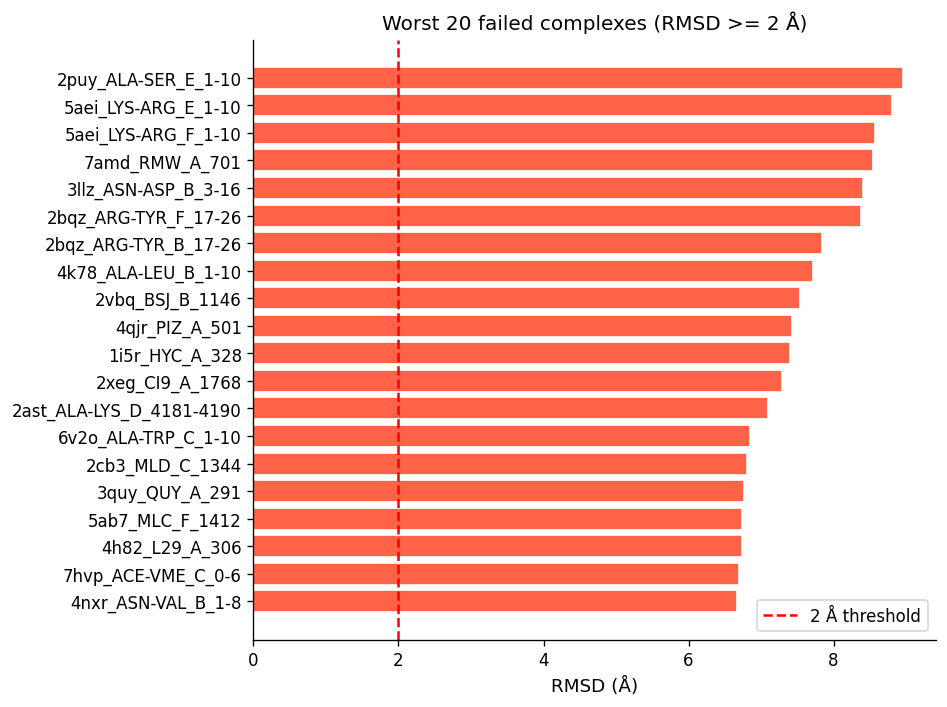

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
top_failures = failures.head(20).sort_values('rmsd')
ax.barh(top_failures['complex_id'], top_failures['rmsd'], color='tomato', edgecolor='white')
ax.axvline(2.0, color='red', linestyle='--', linewidth=1.5, label='2 Å threshold')
ax.set_xlabel('RMSD (Å)', fontsize=11)
ax.set_title('Worst 20 failed complexes (RMSD >= 2 Å)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('failures_full.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Cumulative Success Curve

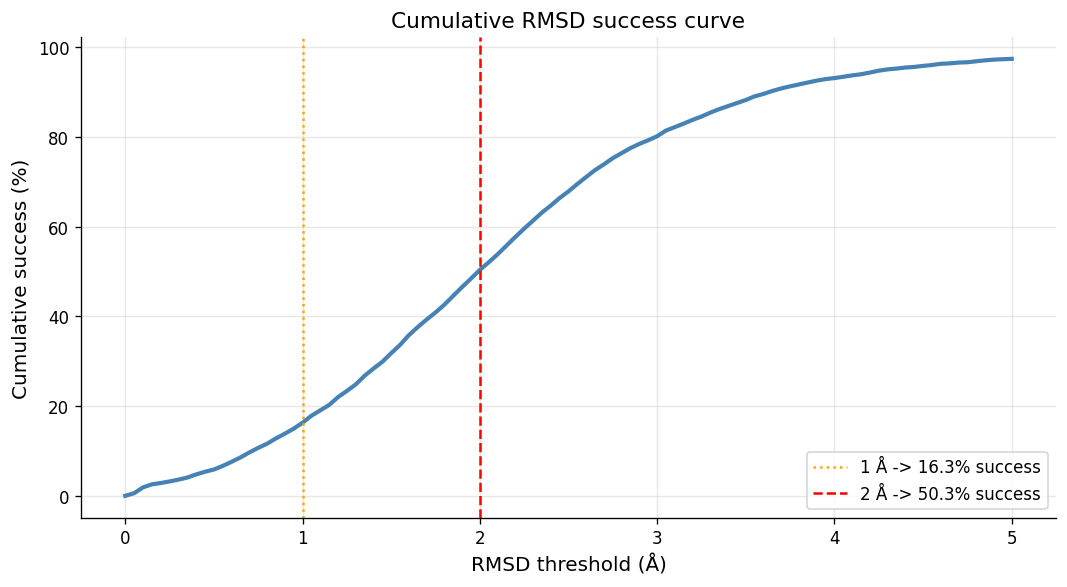

In [32]:
thresholds  = np.arange(0.0, 5.01, 0.05)
success_pct_curve = [(eval_df['rmsd'] < t).mean() * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, success_pct_curve, color='steelblue', linewidth=2.5)
ax.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label=f'1 Å -> {success_1A:.1f}% success')
ax.axvline(2.0, color='red', linestyle='--', linewidth=1.5, label=f'2 Å -> {success_2A:.1f}% success')
ax.set_xlabel('RMSD threshold (Å)', fontsize=12)
ax.set_ylabel('Cumulative success (%)', fontsize=12)
ax.set_title('Cumulative RMSD success curve', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_success_full.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Full Results Table (Top-1 poses)

In [33]:
display_df = eval_df[['complex_id', 'ligand_code', 'pdb_id', 'rmsd', 'rmsd_lt2', 'rmsd_lt1', 'pb_valid']].copy()
display_df = display_df.sort_values('rmsd').reset_index(drop=True)

def highlight_fail(row):
    if not row['rmsd_lt2']:
        return ['background-color: #ffe0e0'] * len(row)
    elif not row['rmsd_lt1']:
        return ['background-color: #fffde0'] * len(row)
    else:
        return ['background-color: #e8f5e9'] * len(row)

display_df.style.apply(highlight_fail, axis=1).format({'rmsd': '{:.4f}'})

## PoseBusters-Filtered Benchmark Comparison

A separate, smaller (308-complex) curated benchmark with non-standard residues, evaluated the same way as the main test set, for comparison.

--------------------------------------------------
  DiffDock-Pocket — PoseBusters-Filtered Results
--------------------------------------------------
  Complexes evaluated  : 306
  RMSD < 2.0 Å (Top-1) : 60.8%  (186/306)
  RMSD < 1.0 Å (Top-1) : 22.9%  (70/306)
  PoseBusters valid    : 3.9%  (12/306)

                       Main Test Set  PoseBusters-Filtered
RMSD < 2Å (%)              50.349108             60.784314
RMSD < 1Å (%)              16.291699             22.875817
PoseBusters valid (%)       6.613654              3.921569


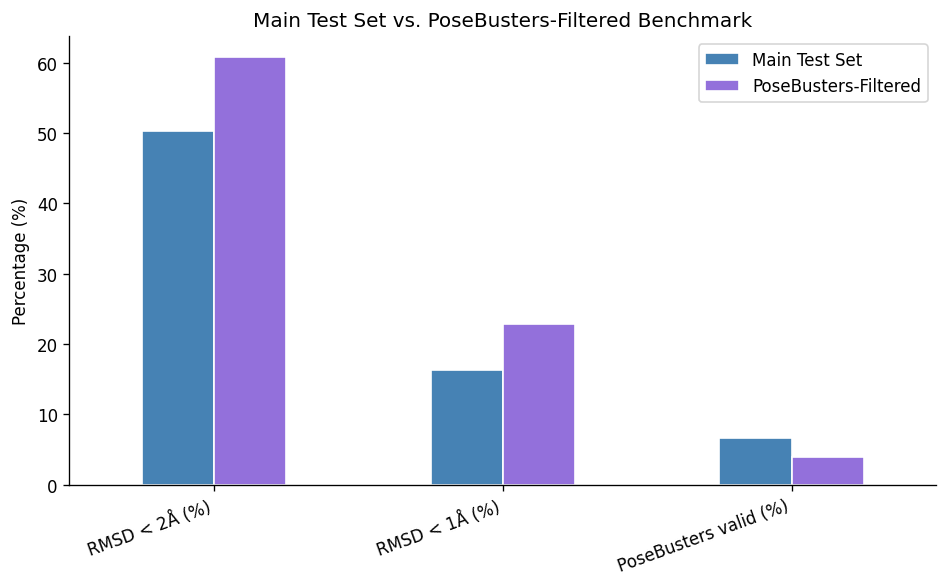

In [40]:
pb_filtered_all = pd.read_csv(POSEBUSTERS_FILTERED_CSV_PATH)
pb_filtered = pb_filtered_all[pb_filtered_all['pose_rank'] == 1].copy()

n_pbf = len(pb_filtered)
success_2A_pbf = pb_filtered['rmsd_lt2'].mean() * 100
success_1A_pbf = pb_filtered['rmsd_lt1'].mean() * 100
pb_valid_pbf = pb_filtered['pb_valid'].mean() * 100

print('-' * 50)
print('  DiffDock-Pocket — PoseBusters-Filtered Results')
print('-' * 50)
print(f'  Complexes evaluated  : {n_pbf}')
print(f'  RMSD < 2.0 Å (Top-1) : {success_2A_pbf:.1f}%  ({pb_filtered["rmsd_lt2"].sum()}/{n_pbf})')
print(f'  RMSD < 1.0 Å (Top-1) : {success_1A_pbf:.1f}%  ({pb_filtered["rmsd_lt1"].sum()}/{n_pbf})')
print(f'  PoseBusters valid    : {pb_valid_pbf:.1f}%  ({pb_filtered["pb_valid"].sum()}/{n_pbf})')

# side-by-side comparison with main test set
benchmark_comparison = pd.DataFrame({
    'Main Test Set': [success_2A, success_1A, pb_valid_pct],
    'PoseBusters-Filtered': [success_2A_pbf, success_1A_pbf, pb_valid_pbf],
}, index=['RMSD < 2Å (%)', 'RMSD < 1Å (%)', 'PoseBusters valid (%)'])

print()
print(benchmark_comparison)

fig, ax = plt.subplots(figsize=(8, 5))
benchmark_comparison.plot(kind='bar', ax=ax, color=['steelblue', 'mediumpurple'], edgecolor='white')
ax.set_ylabel('Percentage (%)')
ax.set_title('Main Test Set vs. PoseBusters-Filtered Benchmark')
ax.set_xticklabels(benchmark_comparison.index, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Metric | Value |
|---|---|
| Complexes evaluated | *(from section 4)* |
| RMSD < 2.0 Å (Top-1, 3 poses) | 50.3% |
| RMSD < 1.0 Å (Top-1, 3 poses) | *(from section 4)* |
| PoseBusters valid (3 poses) | 6.6% |
| RMSD < 2.0 Å (Top-1, 1 pose) | 50.2% |
| PoseBusters valid (1 pose) | 5.4% |
| Median RMSD | *(from section 4)* |
| Best validation-loss epoch | *(from section 2)* |
| Total epochs trained | *(from section 2)* |


**Discussion**

**Training** 
Moving to the full LP-HiQBind dataset (24,165 train / 2,684 val complexes) required going from a Tesla P100 (16GB, insufficient for ESM embedding computation) to an A100-PCIE-40GB. Even there, batch size was reduced from the original paper's 16 to 4 to avoid OOM, and receptor_radius/c_alpha_max_neighbors were reduced (15→10, 24→16) for memory. Learning rate required experimentation: 1e-3 and a short 1e-4 trial both diverged, settling on 1e-5 with gradient clipping; AMP was tried for memory relief but caused NaN loss and was reverted. Training ran 108 of the paper's 750 target epochs (~14%). Training loss stayed flat (0.98–1.01) throughout; validation loss swung wildly (up to 10^29) from division by small sigma values for some complexes. Epoch 4 gave the lowest validation loss (645.32) and was never beaten across the remaining 104 epochs.

**Inference**
The Epoch 4 checkpoint (best_ema_model.pt) was used on the full 5,426-complex test set. The paper's 40-poses-with-reranking setting was projected at ~18 days on a single GPU, so samples_per_complex=1 was used (~11 hours), with a separate 3-pose comparison also run. A CUDA device-side assert crash (misleadingly traced by CUDA's async reporting to model.to(device)) required an 8-step investigation before the real cause was found: ESM protein embeddings accumulating in GPU VRAM across all 5,426 complexes before the score model loaded. A .cpu() fix resolved it. 4,950 of 4,967 loaded complexes (99.66%) completed inference.

**Evaluation**
Using the unmodified evaluation.py, results were ~50.2% RMSD < 2Å but only ~5% PoseBusters-valid. The original paper reports 17.4% (crystal) / 10.9% (ESMFold) on this same combined metric but under far greater resources: 750 epochs vs. our 108, batch size 16 vs. 4, and 40 reranked samples vs. our 1 and 3 rereanked poses. Given that gap at every stage, our ~5% being 3–3.5x lower than the paper's figure is expected, not a sign of a broken pipeline. Three compounding factors: (1) Epoch 4 is an early checkpoint the model had barely begun learning; (2) reduced batch size and receptor context noisier gradients and less local structure per complex than the paper's config; (3) single-GPU ceiling forcing samples_per_complex= 1 and 3 no confidence-model reranking to discard poses violating bond lengths, angles, clashes, or chirality, which the paper's headline numbers rely on. The PoseBusters-filtered benchmark (308 complexes) showed the same pattern: ~60.8% RMSD < 2Å, ~3.9% PB-valid (3 poses/complex).